# Viz_V6 — Route A Result Visualization

Reads CSV + JSON from `results/<DATE_FOLDER>/` (produced by `train.py --route A`).
All figures are saved to the same date folder as PDF.
**Edit Cell 1 to set paths and style overrides.**

**V6.0 metrics:**
- **L1** — ExMatch, Macro ROC-AUC, Macro F1, per-EVCS ROC
- **L2** — L2-b delta-AUC (**PRIMARY**), L2-a IG, Aux attack-type accuracy
- **MIA** — reference only (downgraded in V6.0)
- **Efficiency** — wall-clock time, peak memory

In [1]:
# Cell 1 — Config (edit here)
# ============================================================
DATE_FOLDER = '2026-04-22_11'   # ← change to your results folder name
BUS_SYSTEM  = '123bus'            # '34bus' or '123bus'
TAG         = 'routeA'           # V6.0 Route A output tag

# Style overrides — passed to apply_style(); see src/visualization.py STYLE dict
STYLE_OVERRIDES = {
    # Font — Times New Roman for all text
    'font_family':   'Times New Roman',
    'fs_label':      26,
    'fs_tick':       20,
    'fs_legend':     20,
    'fs_subtitle':   22,
    'fs_annotation': 18,

    # Colors — 5 methods (Original, GDGU, GIF, IDEA, Retrain-A)
    'colors': {
        'Original':  "#C7CADE",
        'GDGU':      "#F7AC53",
        'GIF':       "#52AADC",
        'IDEA':      "#EC6E66",
        'Retrain':   "#76BC79",
        'Retrain-A': "#0AF612",
    },
    'markers': {
        'Original':  'o',
        'GDGU':      's',
        'GIF':       'D',
        'IDEA':      'P',
        'Retrain':   '^',
        'Retrain-A': '^',
    },
    'ideal_line_color': 'red',
    'grid_alpha':       0.3,
    'bar_alpha':        0.85,
    'bar_edge_color':   'black',
    'bar_edge_width':   0.5,
    'fill_alpha':       0.15,

    # Save
    'save_fmt': 'pdf',
    'save_dpi': 300,
}

In [2]:
# Cell 2 — Setup
import sys, json
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.visualization import (apply_style, load_results, plot_all_v6,
                                plot_l2b_delta_auc, plot_aux_accuracy,
                                plot_l2_heatmap, plot_metric_bars,
                                plot_per_evcs_roc, plot_mia_auc,
                                plot_mia_forget, plot_mia_retain,
                                plot_gu_comparison, plot_time_comparison,
                                plot_memory_usage)

%load_ext autoreload
%autoreload 2

apply_style(STYLE_OVERRIDES)

RESULTS_DIR = PROJECT_ROOT / 'results' / DATE_FOLDER
df, scenarios, backbones = load_results(str(RESULTS_DIR), BUS_SYSTEM, tag=TAG)

# Show metadata from epoch logs if available
log_path = RESULTS_DIR / f'{BUS_SYSTEM}_{TAG}_epoch_logs.json'
if log_path.exists():
    with open(log_path) as f:
        meta = json.load(f).get('_metadata', {})
    print(f"\nTimestamp : {meta.get('timestamp', 'N/A')}")
    print(f"Device   : {meta.get('device', 'N/A')}")
    d = meta.get('data', {})
    print(f"Graphs={d.get('n_graphs')}, Nodes={d.get('n_nodes')}, "
          f"Features={d.get('n_feat')}, EVCS={d.get('n_evcs')}")
    for name, n_params in meta.get('model_params', {}).items():
        print(f"  {name}: {n_params:,} params")

Loaded 750 rows from /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-22_11/123bus_routeA_results_raw.csv
  Backbones : ['GAT', 'GCN', 'GIN']
  Scenarios : ['S1', 'S2', 'S3', 'S4', 'S5']
  Methods   : ['GDGU', 'GIF', 'IDEA', 'Original', 'Retrain']

Timestamp : 2026-04-23 03:44:33
Device   : cuda:0
Graphs=4000, Nodes=132, Features=48, EVCS=5
  GAT: 391,557 params
  GCN: 73,605 params
  GIN: 123,141 params


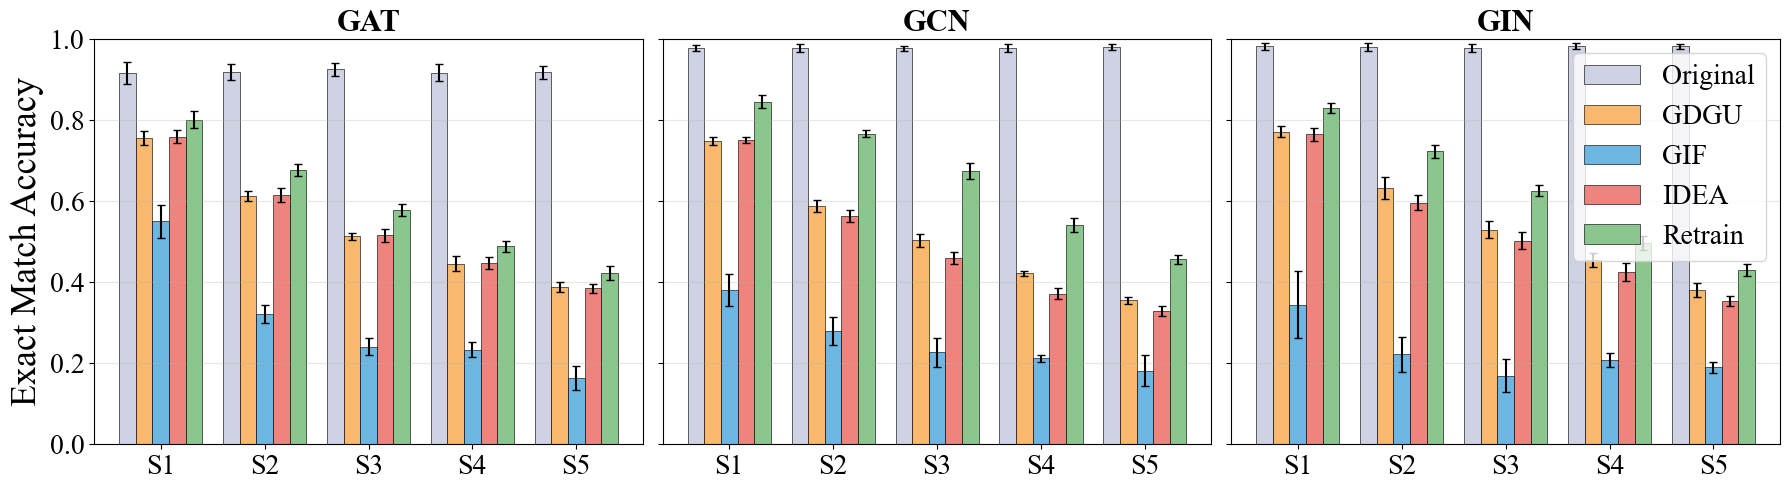

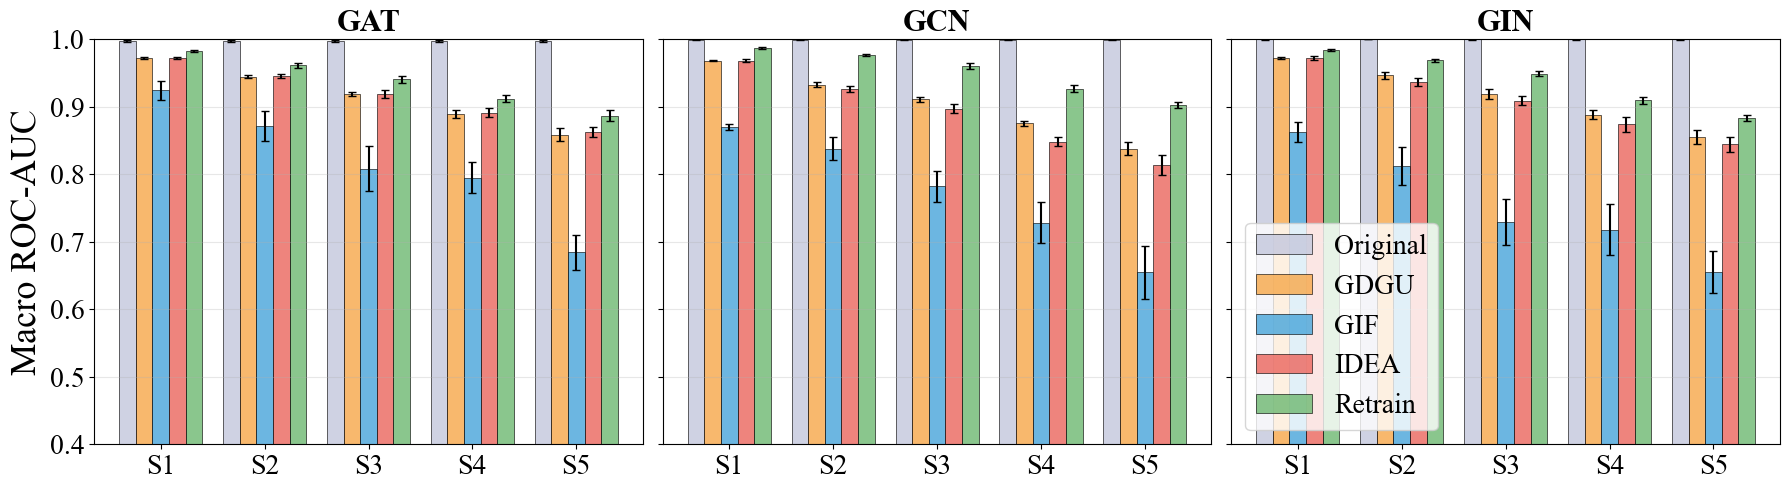

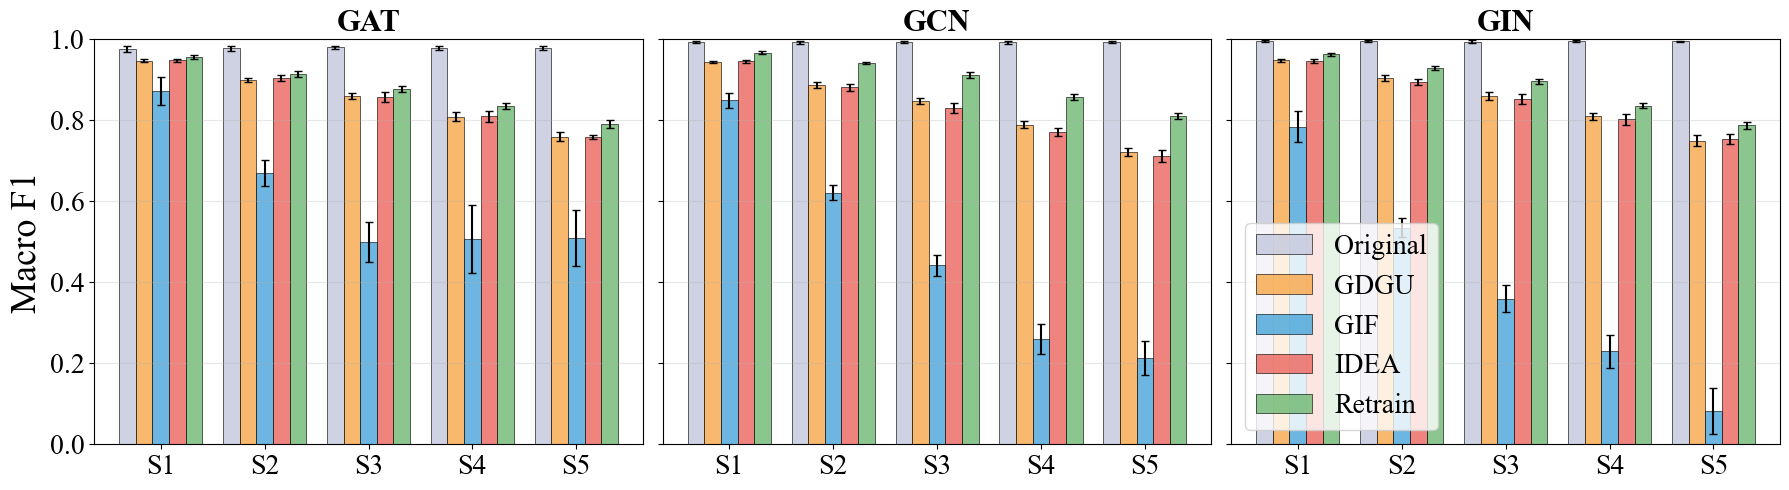

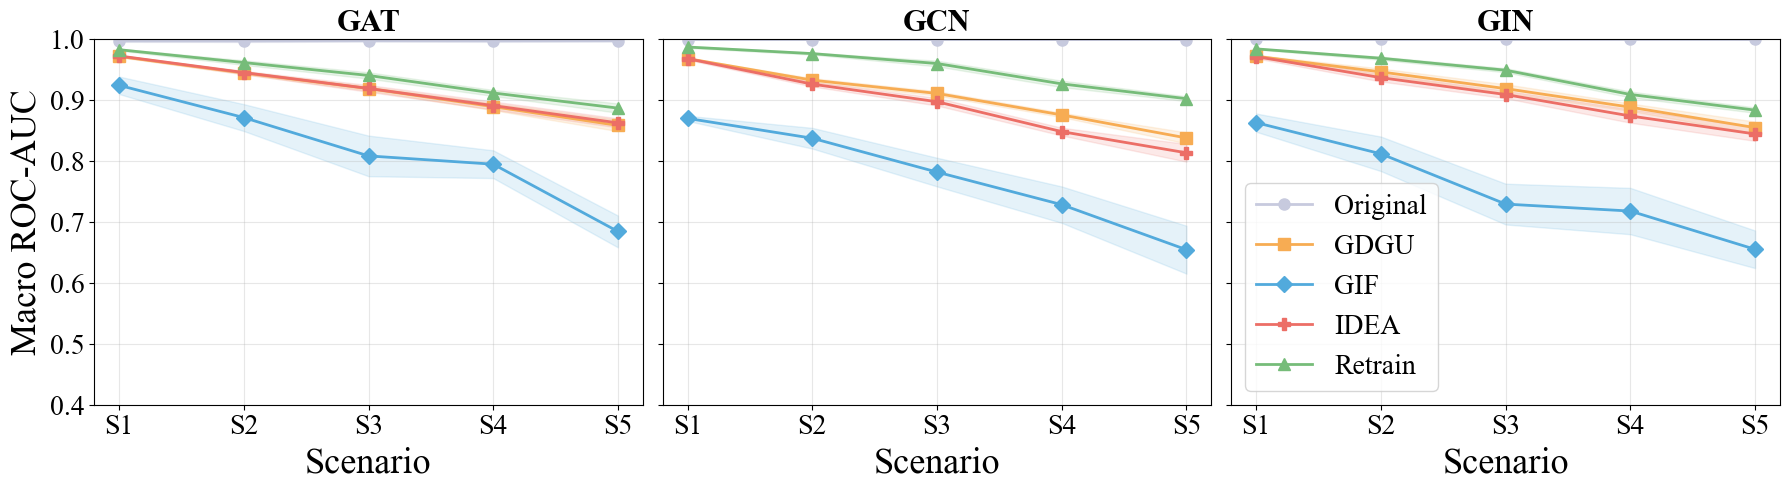

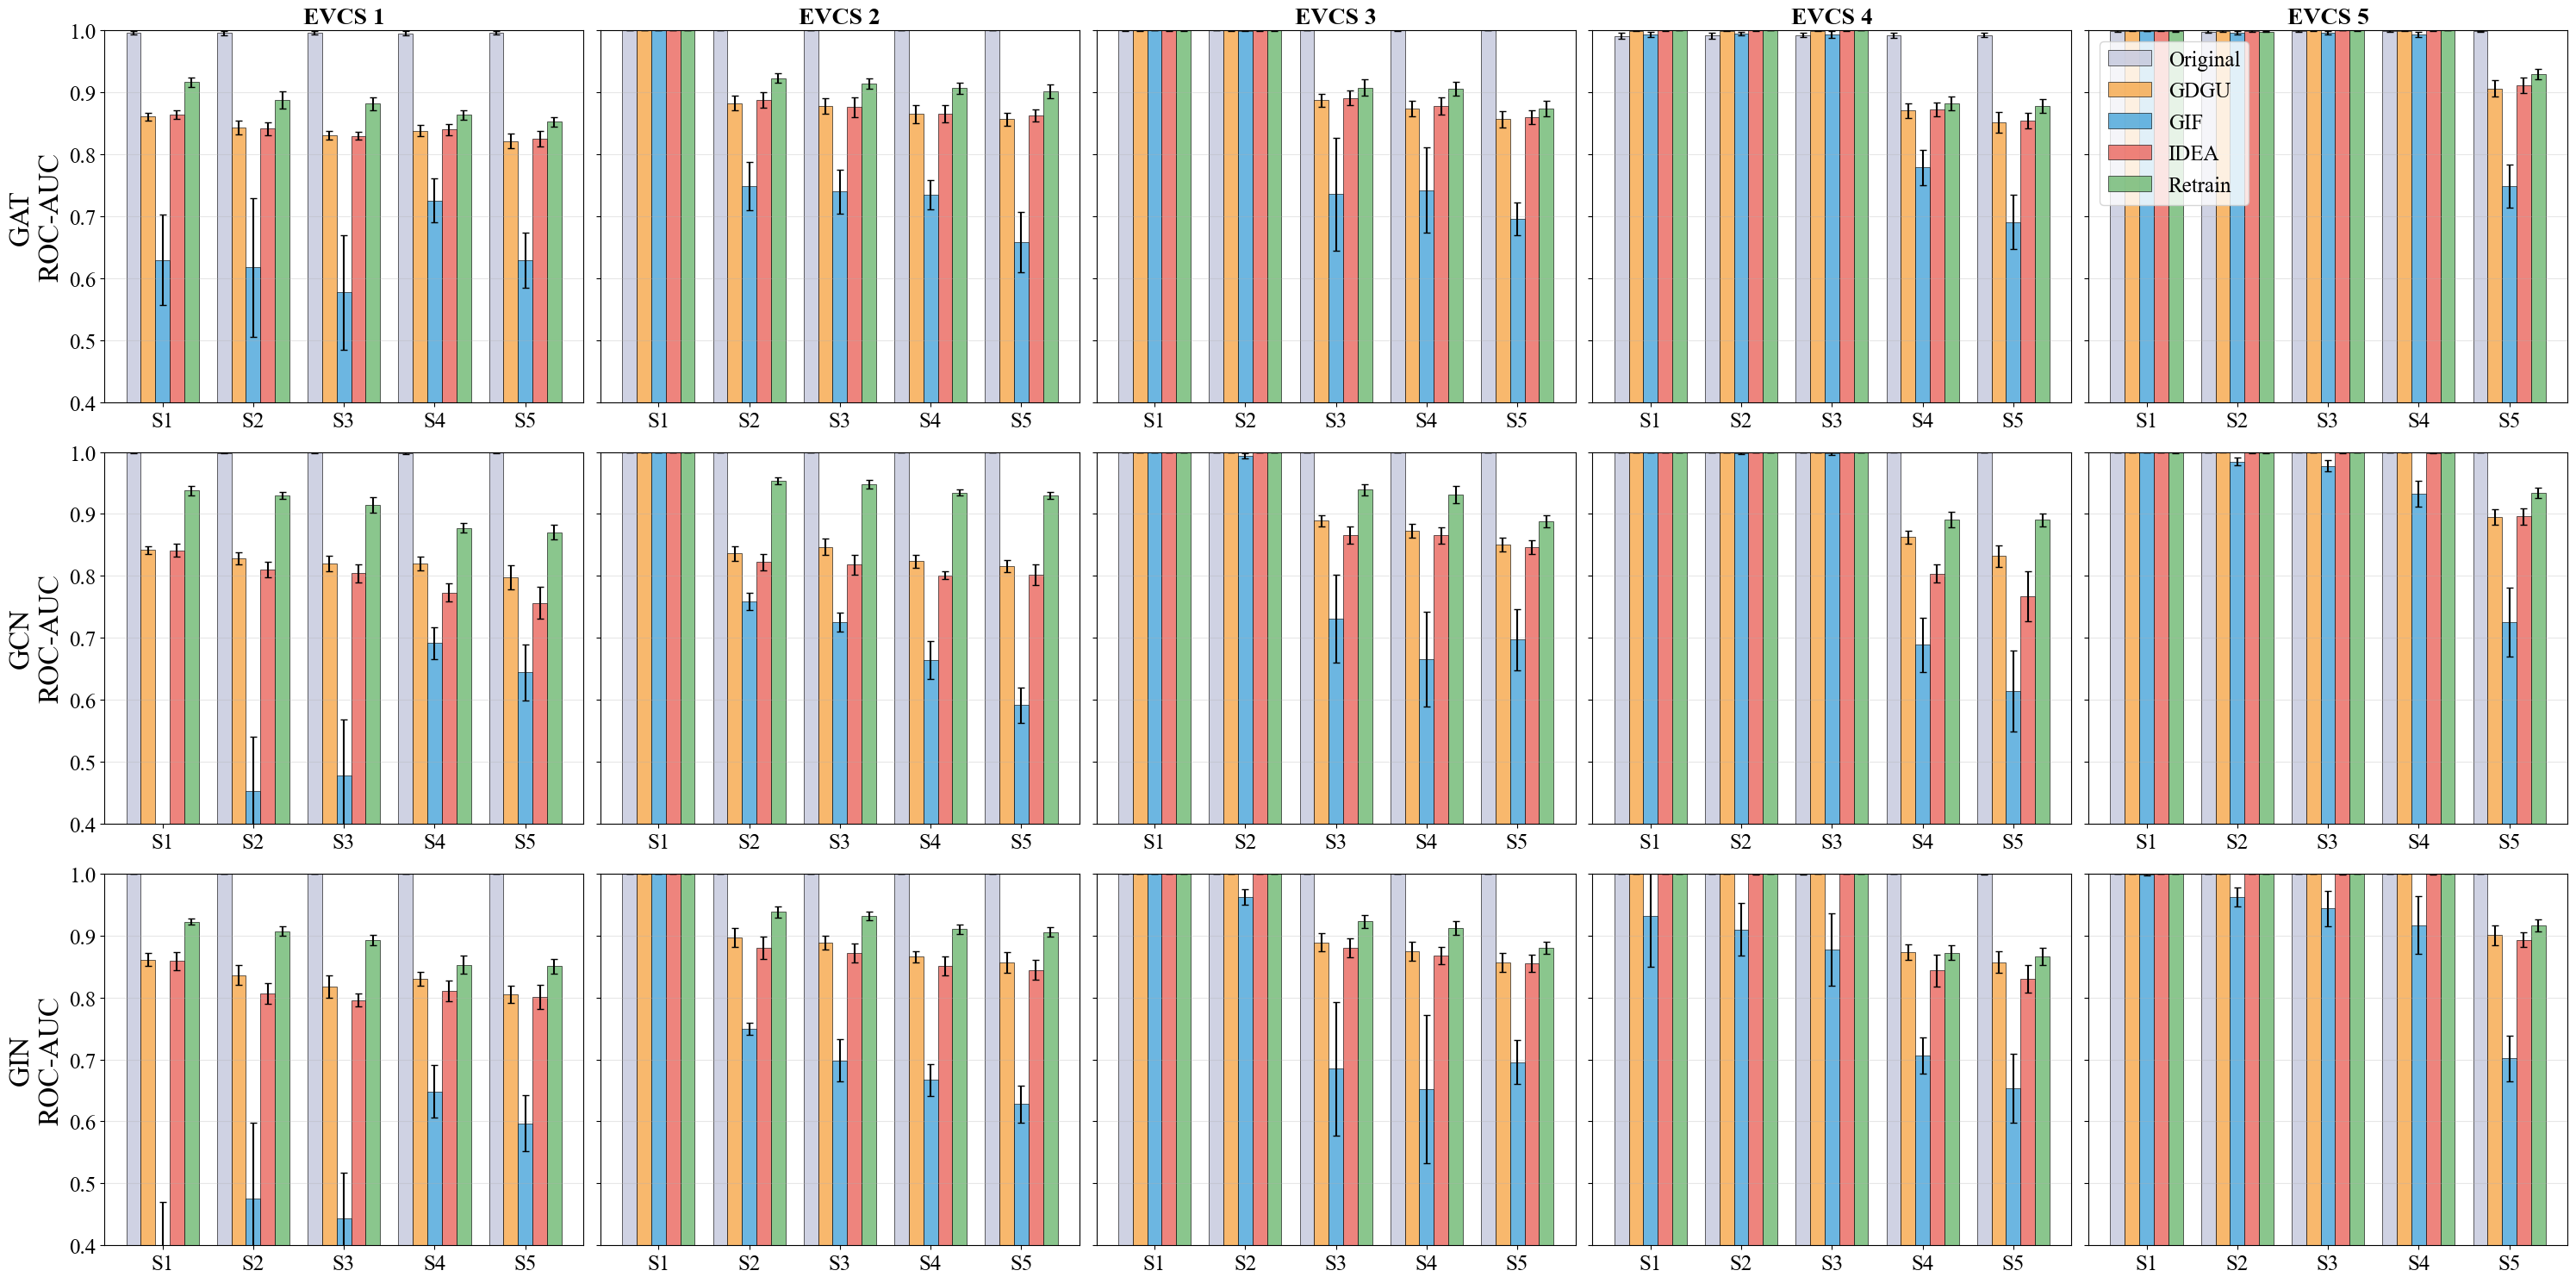

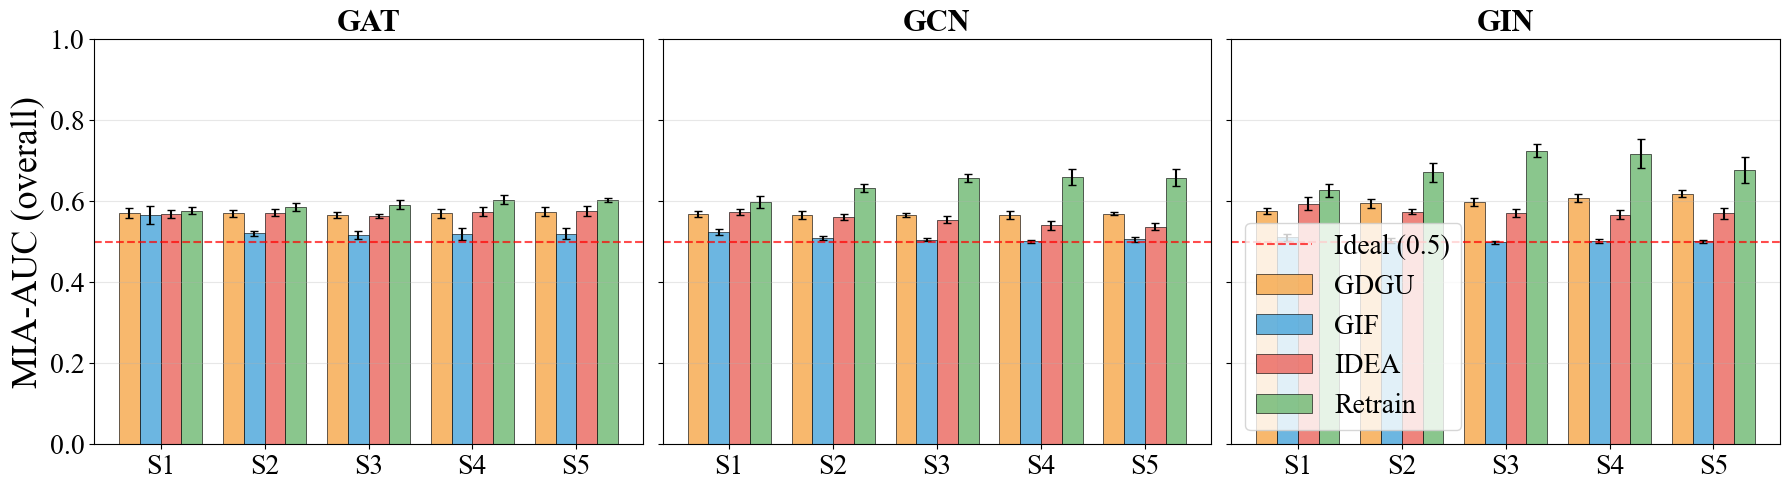

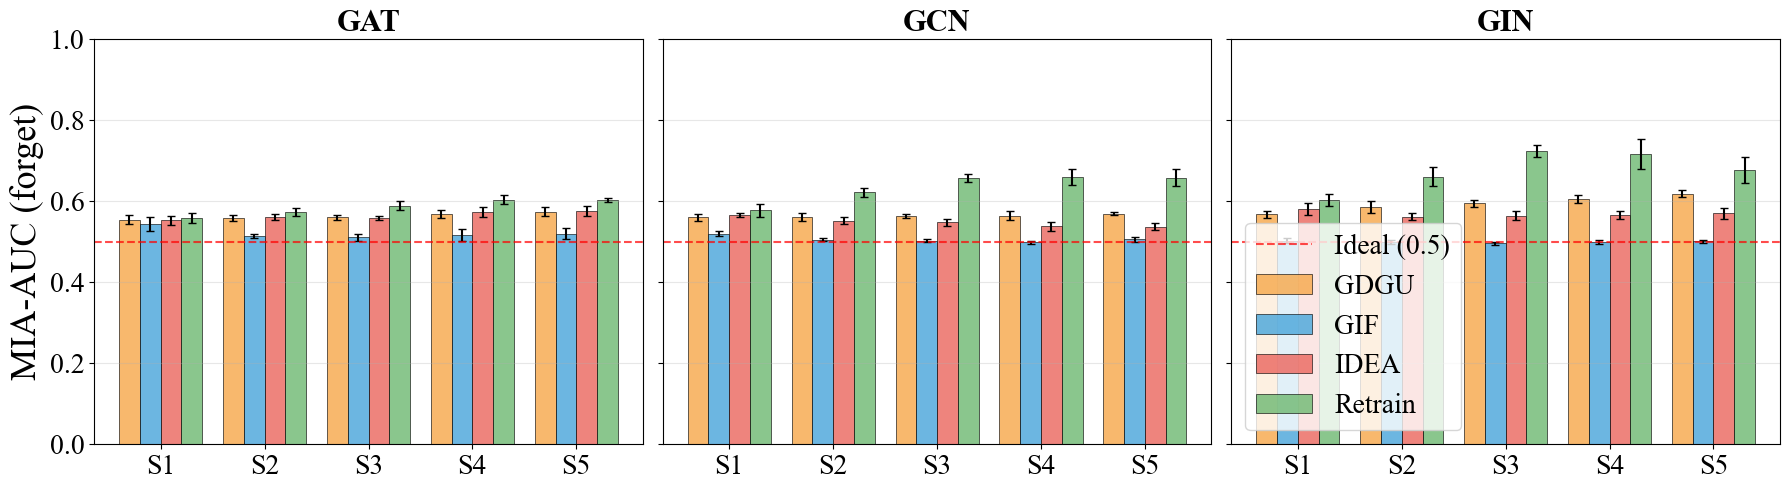

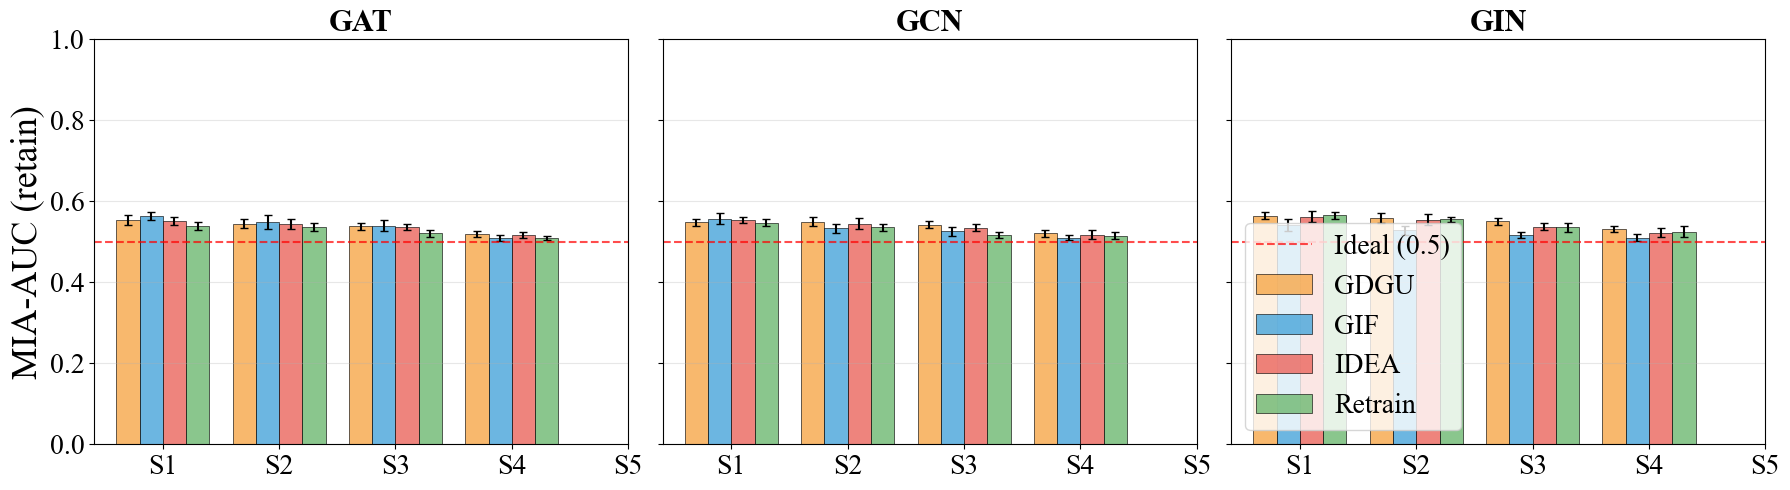

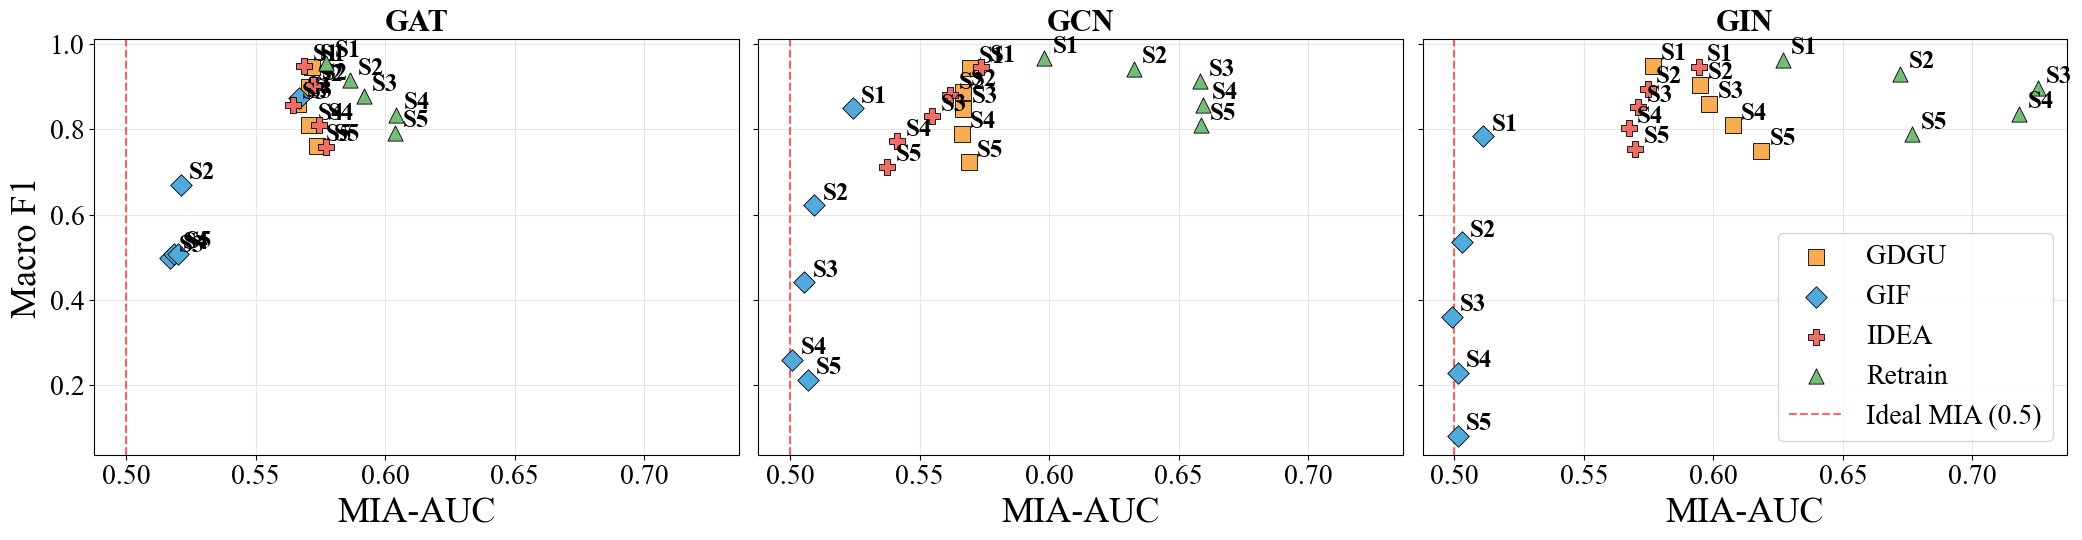

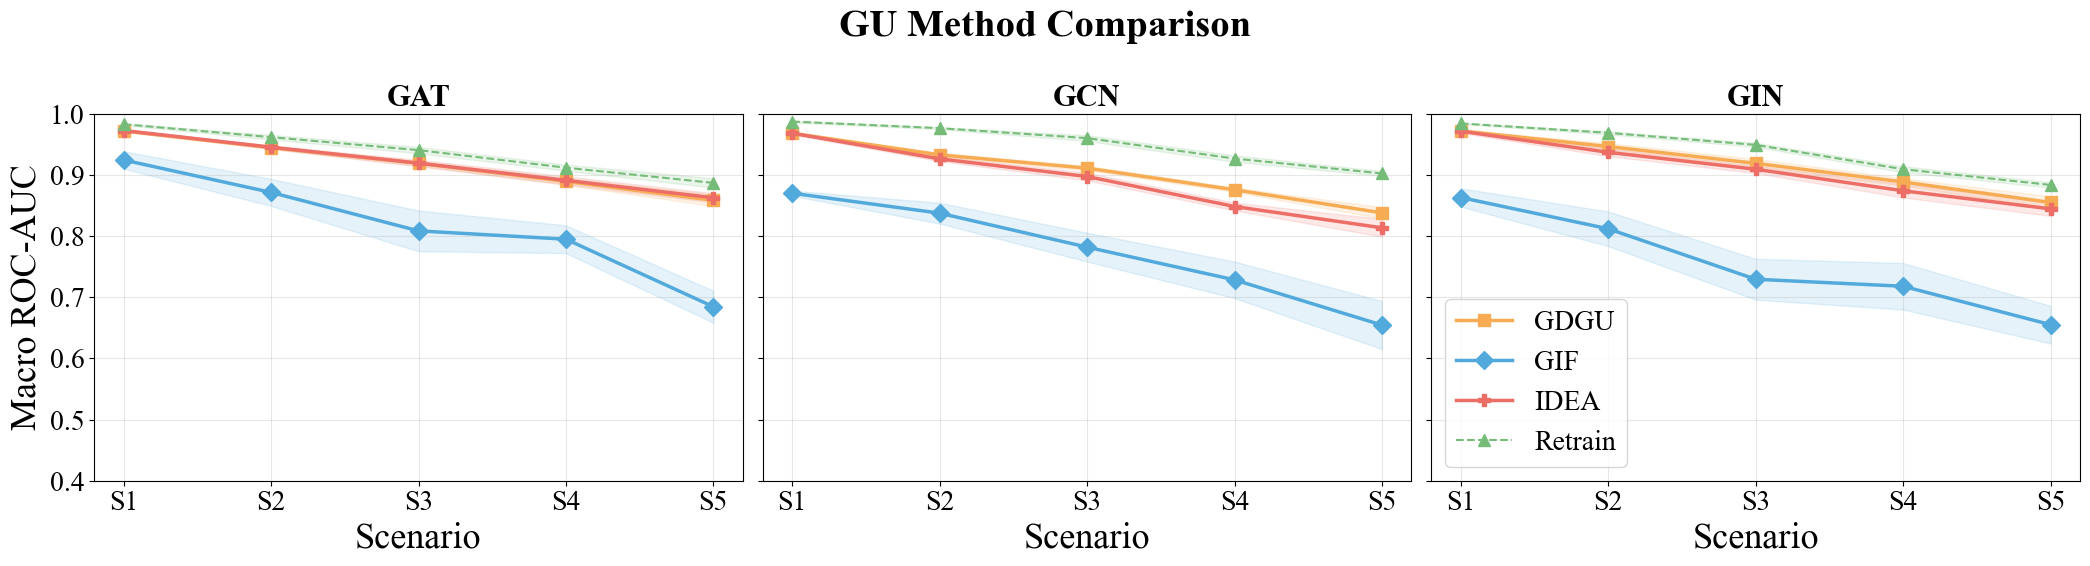

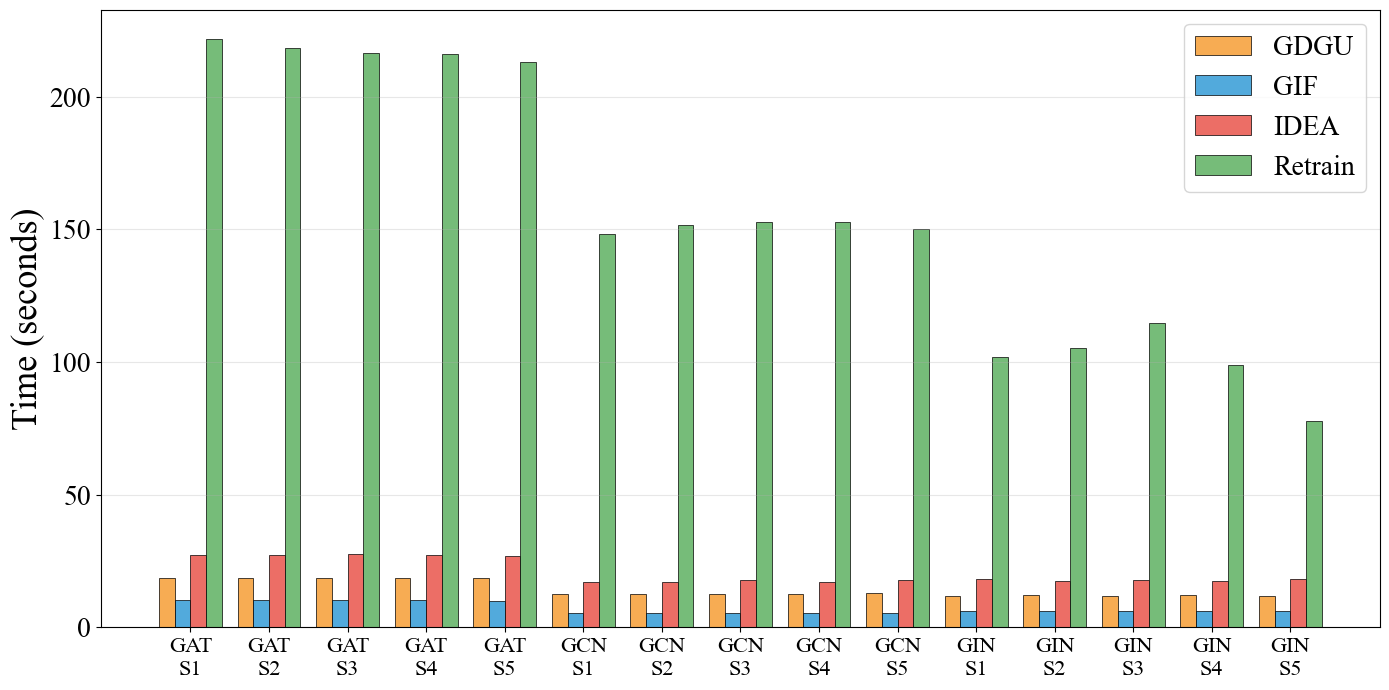

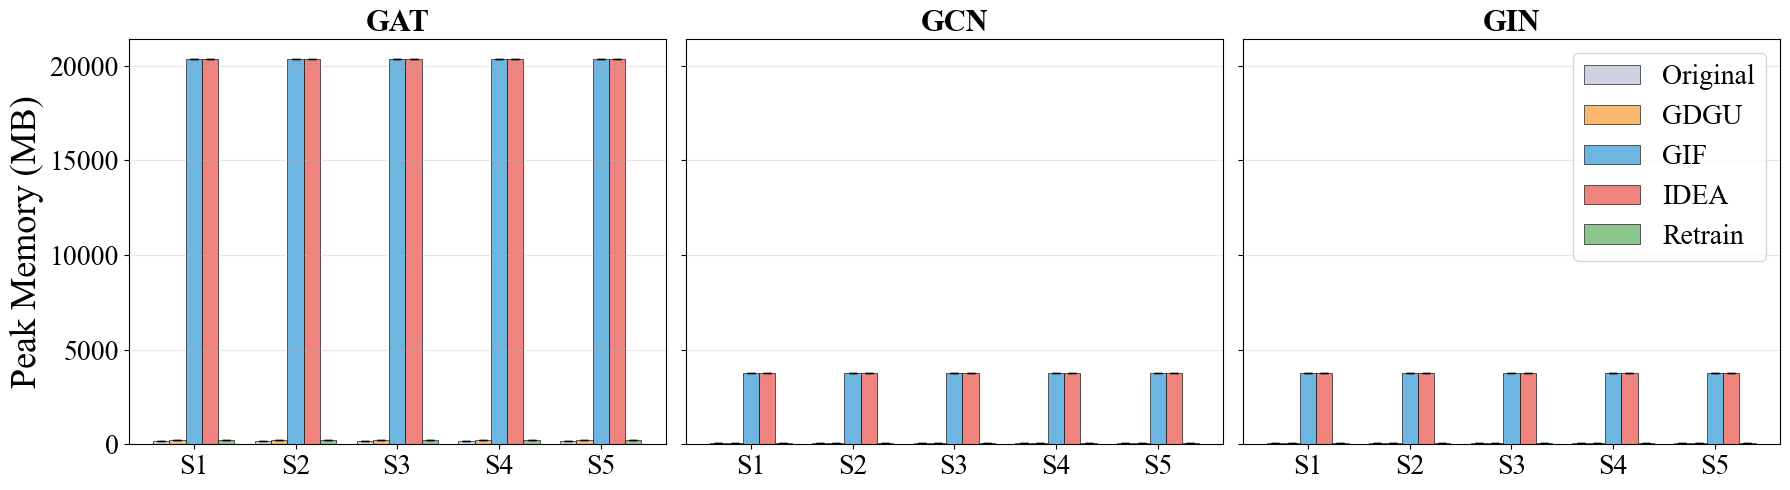

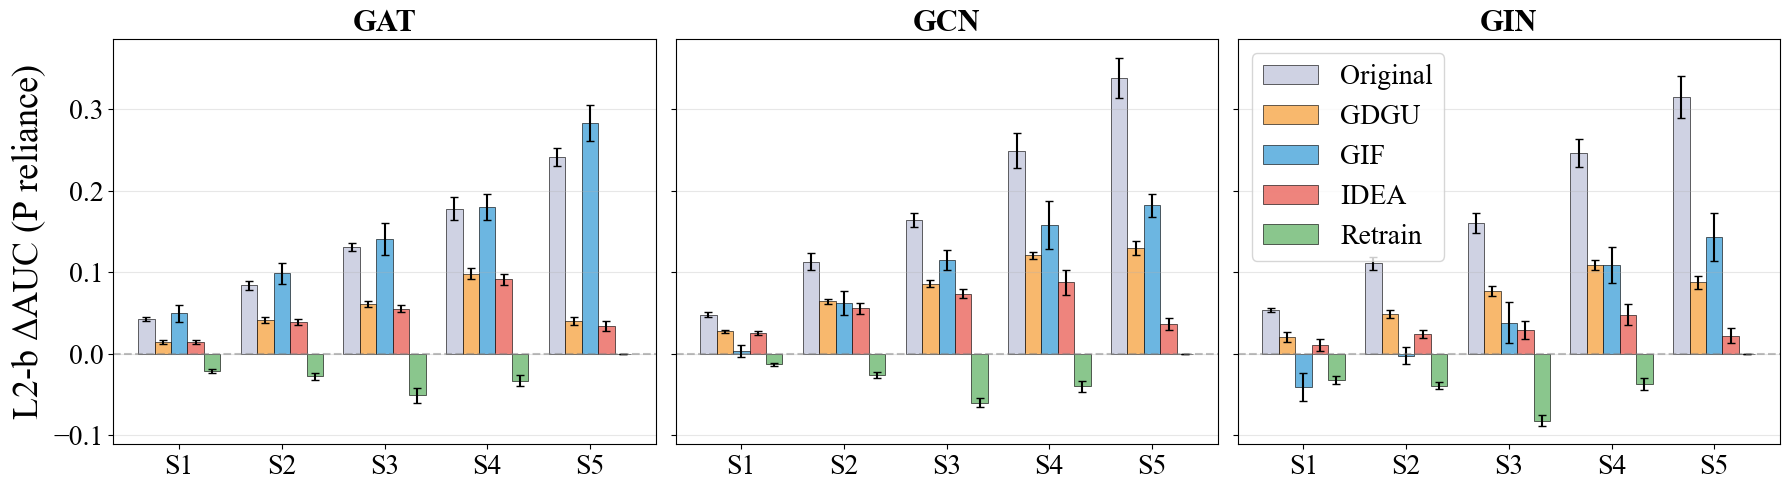

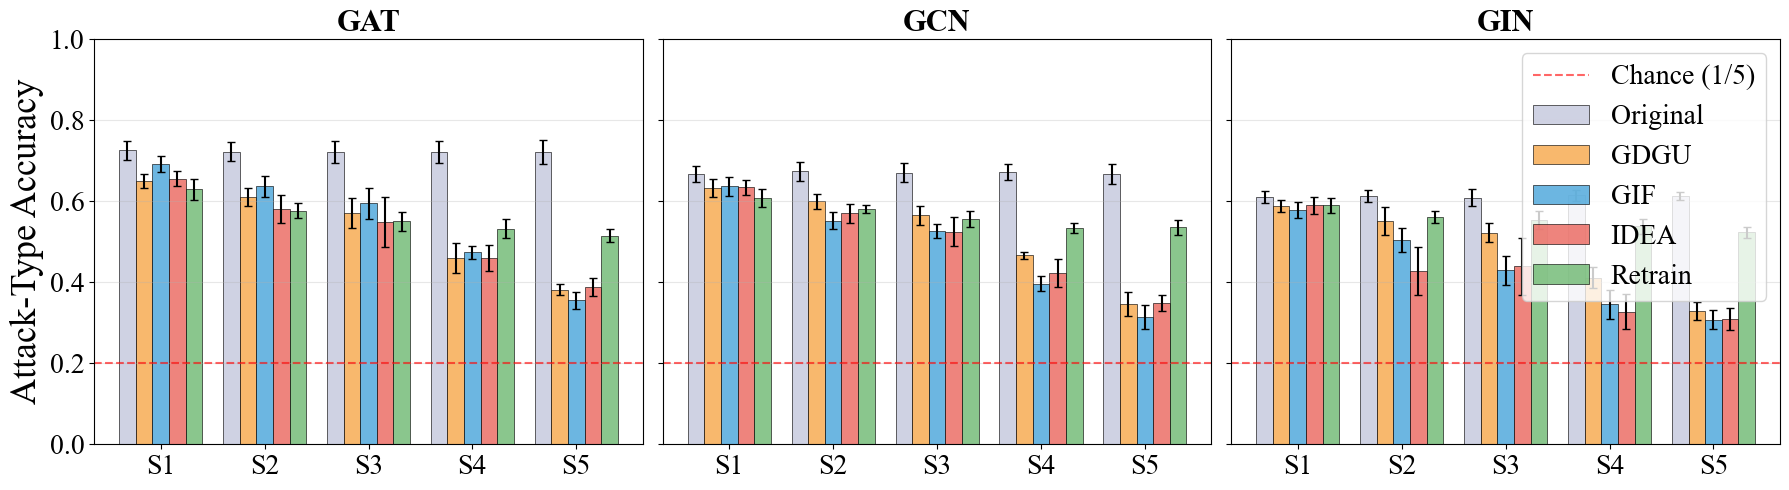

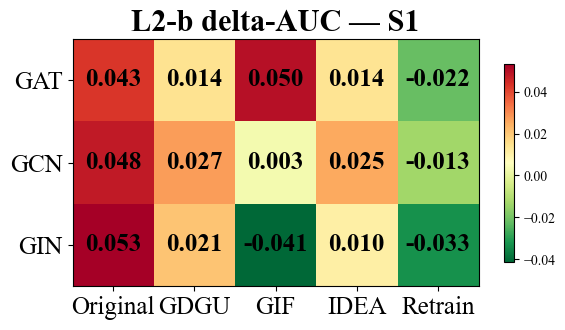

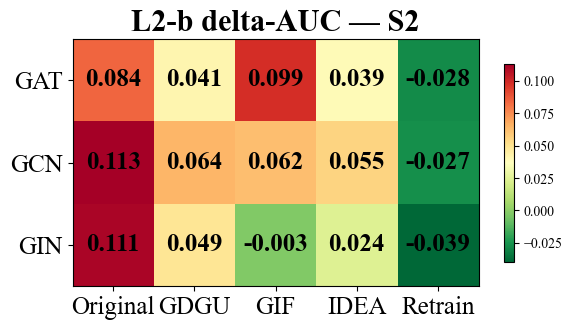

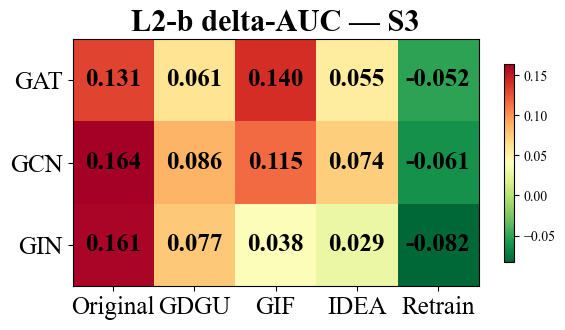

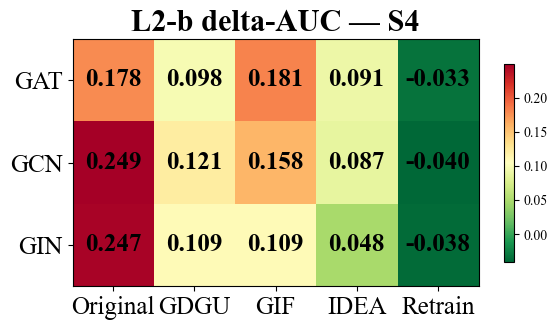

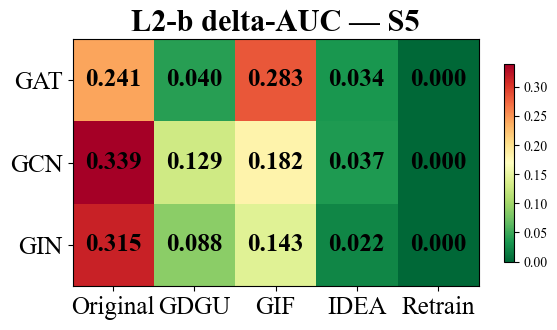

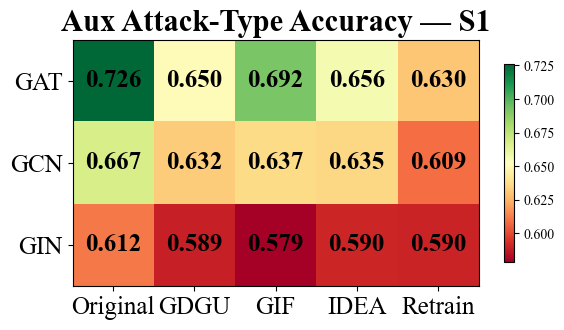

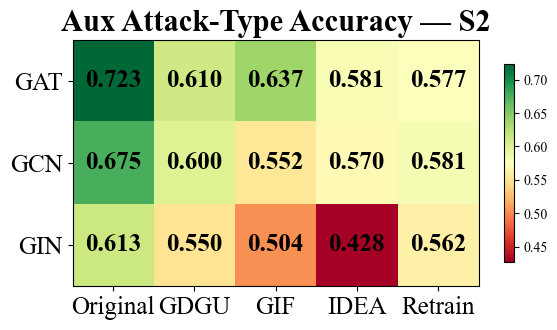

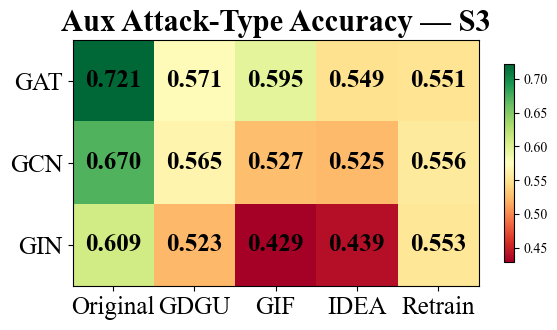

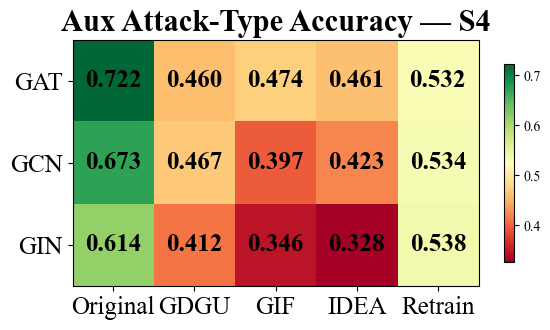

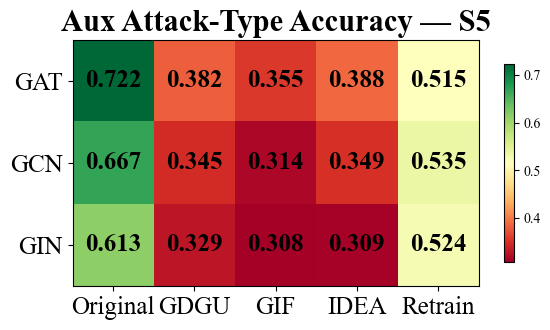


All V6.0 figures saved to /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-22_11/ (prefix: 123bus_)

Figures saved to: /home/Nanhong147/1P_WTT_NVD/Projects/4-GU_EV_loc/results/2026-04-22_11/


In [3]:
# Cell 3 — One-shot: generate all V6.0 figures
plot_all_v6(df, str(RESULTS_DIR), scenarios, backbones, bus_system=BUS_SYSTEM)
print(f'\nFigures saved to: {RESULTS_DIR}/')

## Individual plots (optional — for tweaking)

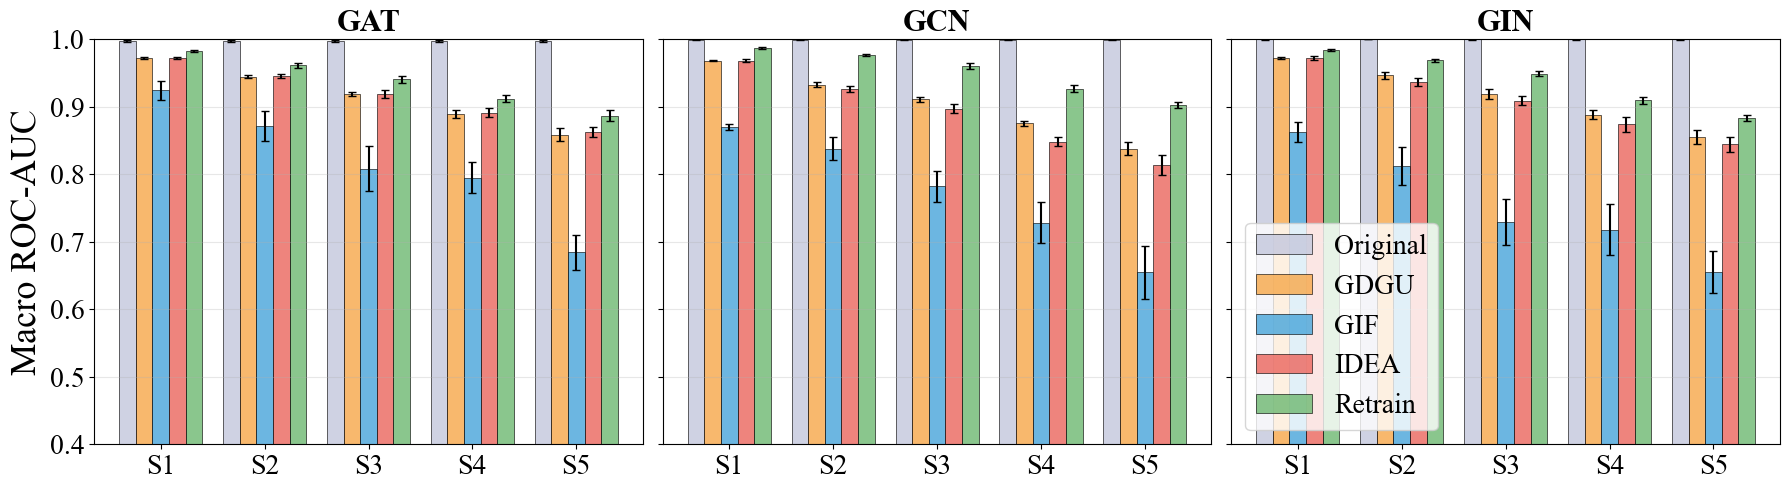

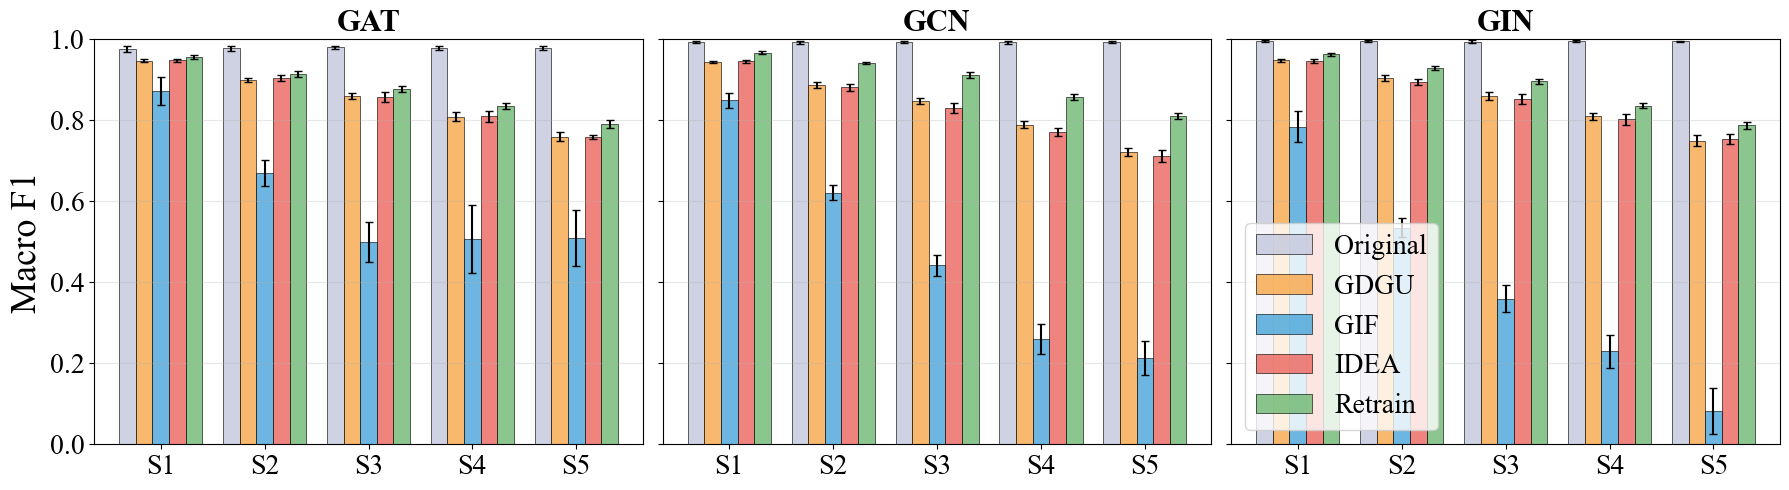

In [4]:
# Cell 4 — L1 utility: Macro ROC-AUC / Macro F1 / ExMatch
plot_metric_bars(df, 'Macro_ROC', 'Macro ROC-AUC', (0.4, 1.0),
                 str(RESULTS_DIR / f'{BUS_SYSTEM}_MacroROC_comparison.pdf'),
                 scenarios, backbones)
plot_metric_bars(df, 'Macro_F1', 'Macro F1', (0.0, 1.0),
                 str(RESULTS_DIR / f'{BUS_SYSTEM}_MacroF1_comparison.pdf'),
                 scenarios, backbones)

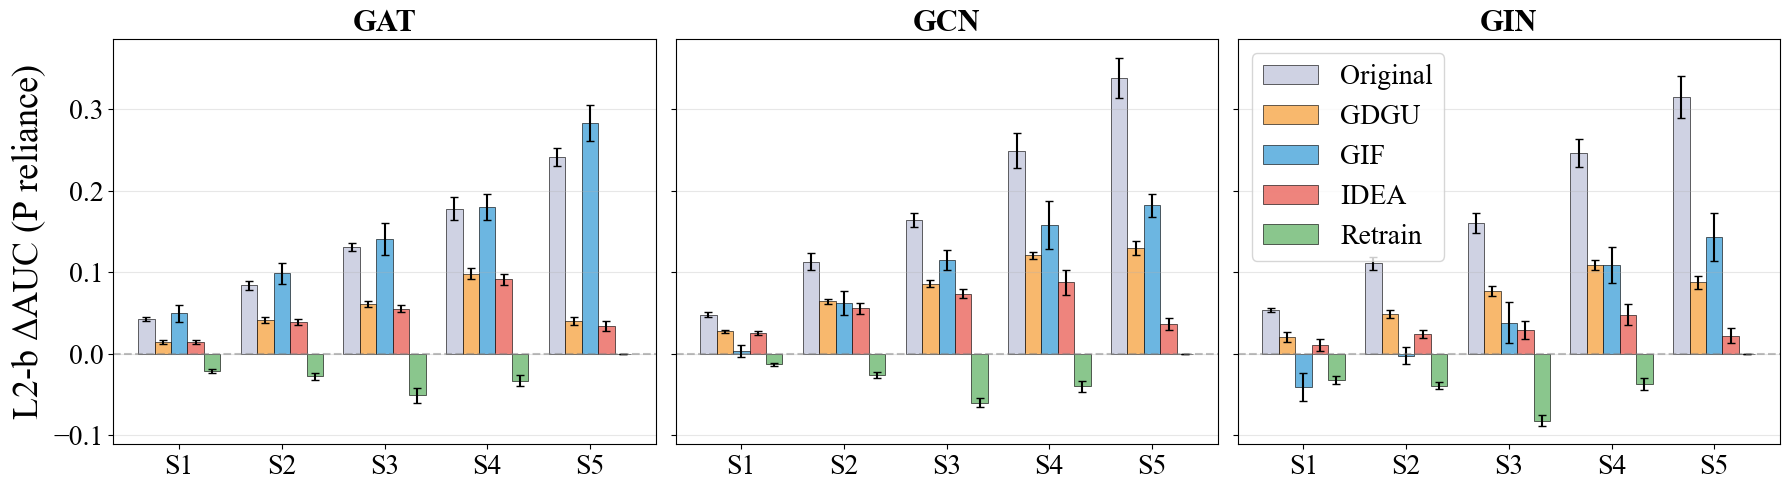

In [5]:
# Cell 5 — L2-b delta-AUC (PRIMARY privacy metric)
# Large positive → model relies heavily on P (not forgotten).
# Near 0 or negative → P has been effectively erased.
plot_l2b_delta_auc(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_L2b_delta_auc.pdf'),
    scenarios, backbones)

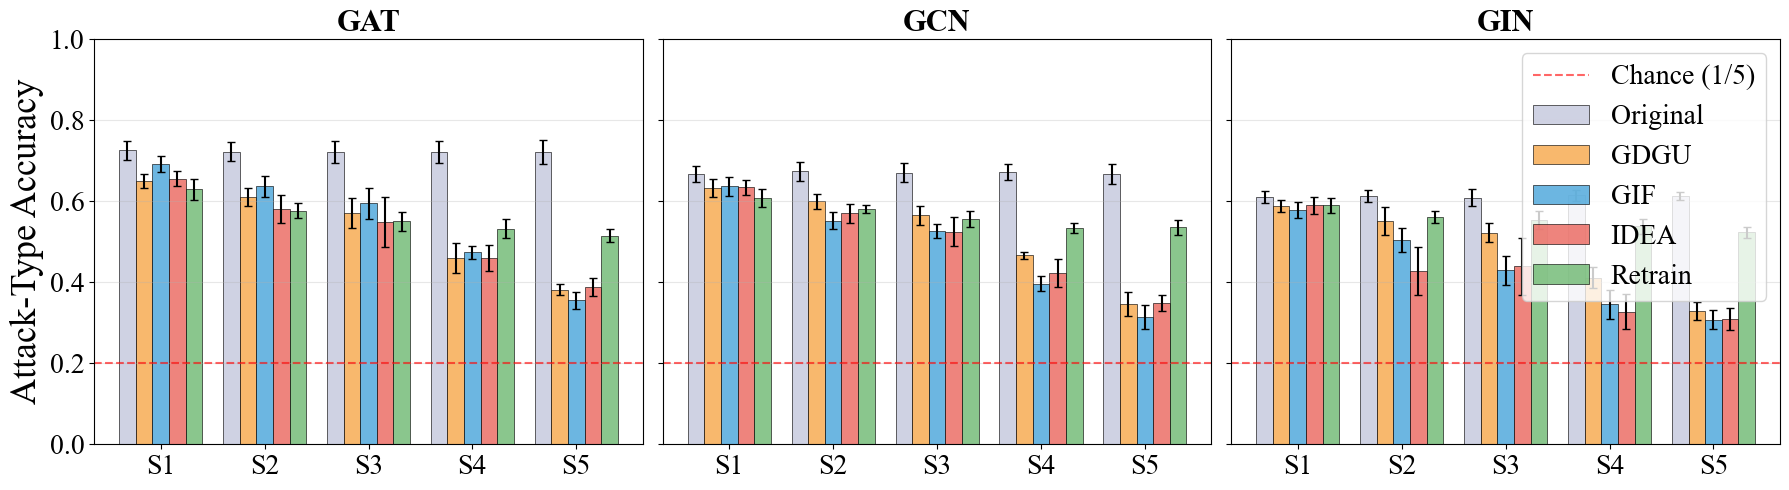

In [6]:
# Cell 6 — Aux attack-type accuracy (L2-e)
plot_aux_accuracy(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Aux_accuracy.pdf'),
    scenarios, backbones)

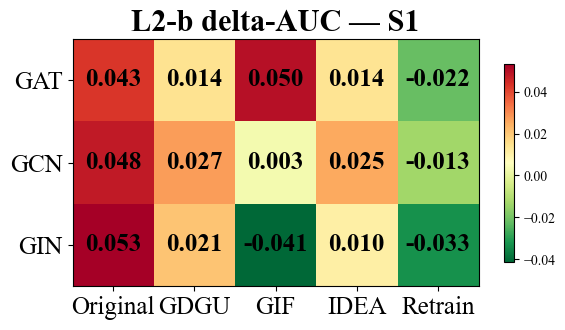

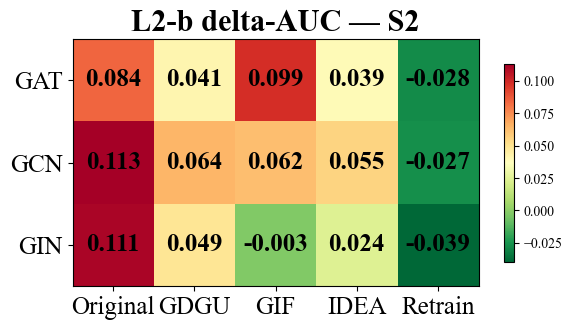

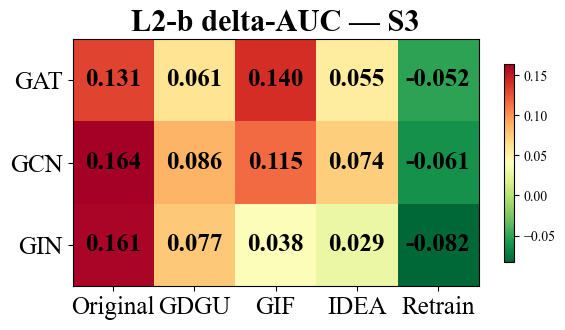

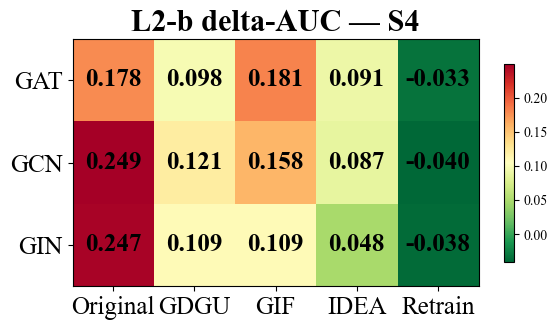

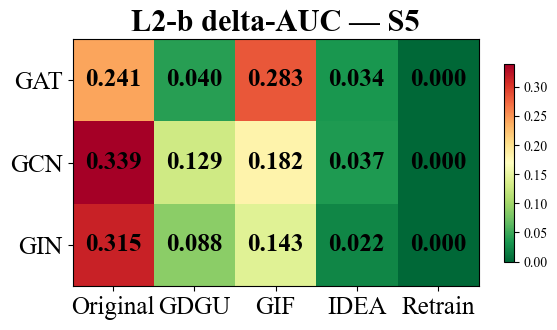

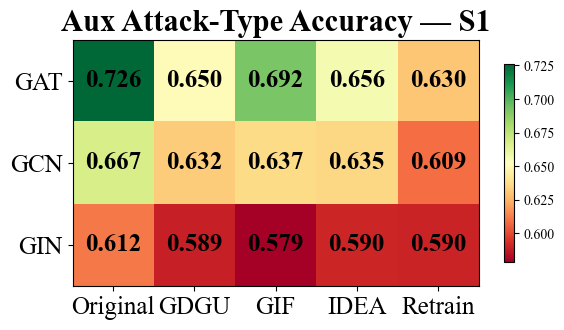

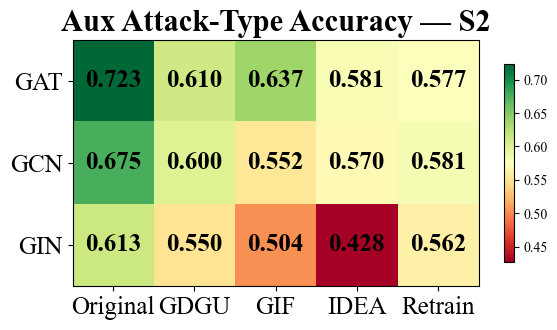

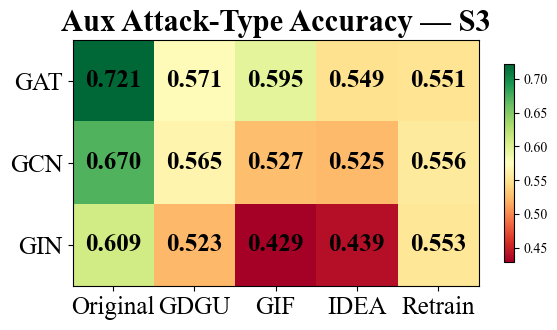

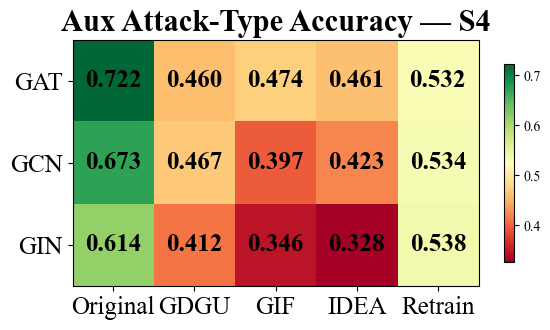

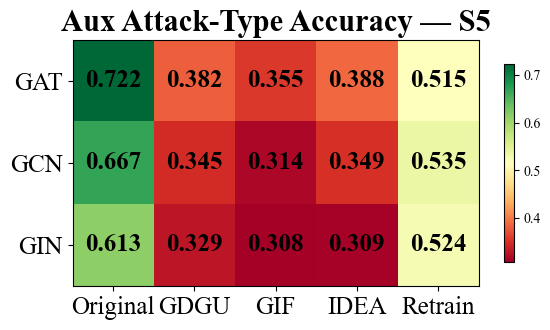

In [7]:
# Cell 7 — L2 heatmaps (method × backbone, one figure per scenario)
plot_l2_heatmap(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_L2b_heatmap.pdf'),
    scenarios, backbones,
    metric='L2b_delta_auc', title='L2-b delta-AUC')

plot_l2_heatmap(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Aux_heatmap.pdf'),
    scenarios, backbones,
    metric='Aux_Acc', title='Aux Attack-Type Accuracy')

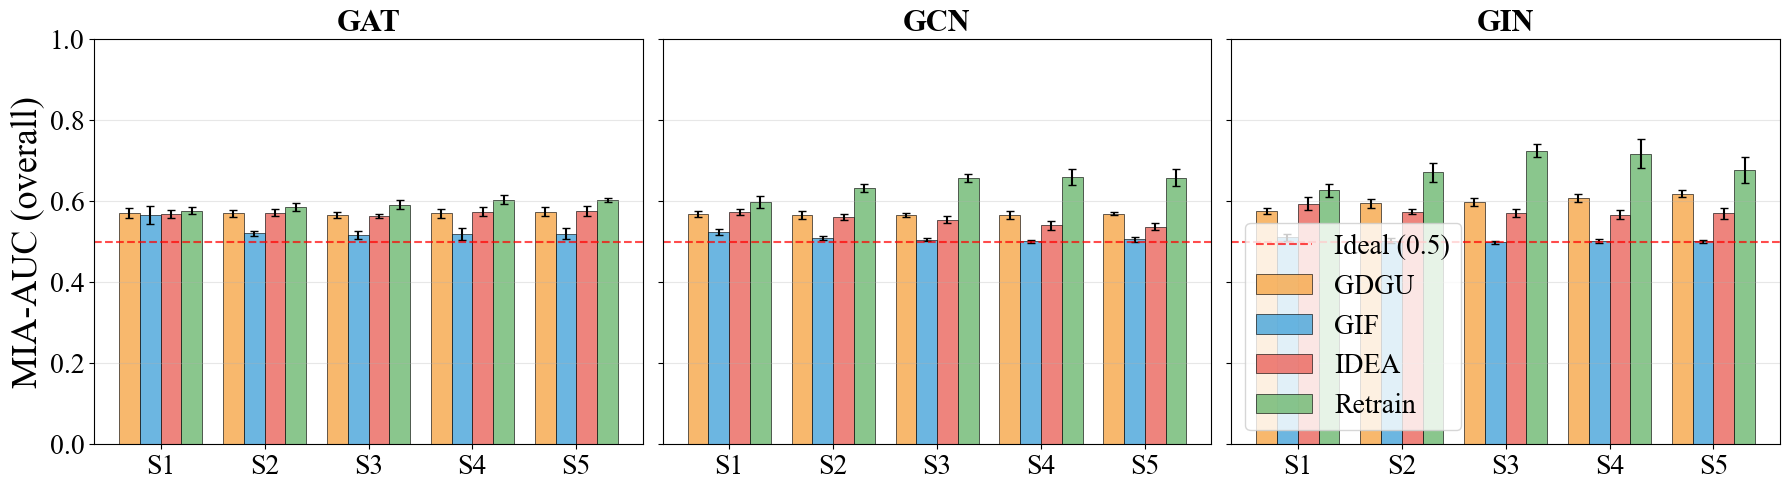

In [8]:
# Cell 8 — MIA (reference only, downgraded in V6.0)
plot_mia_auc(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_MIA_comparison.pdf'),
    scenarios, backbones)

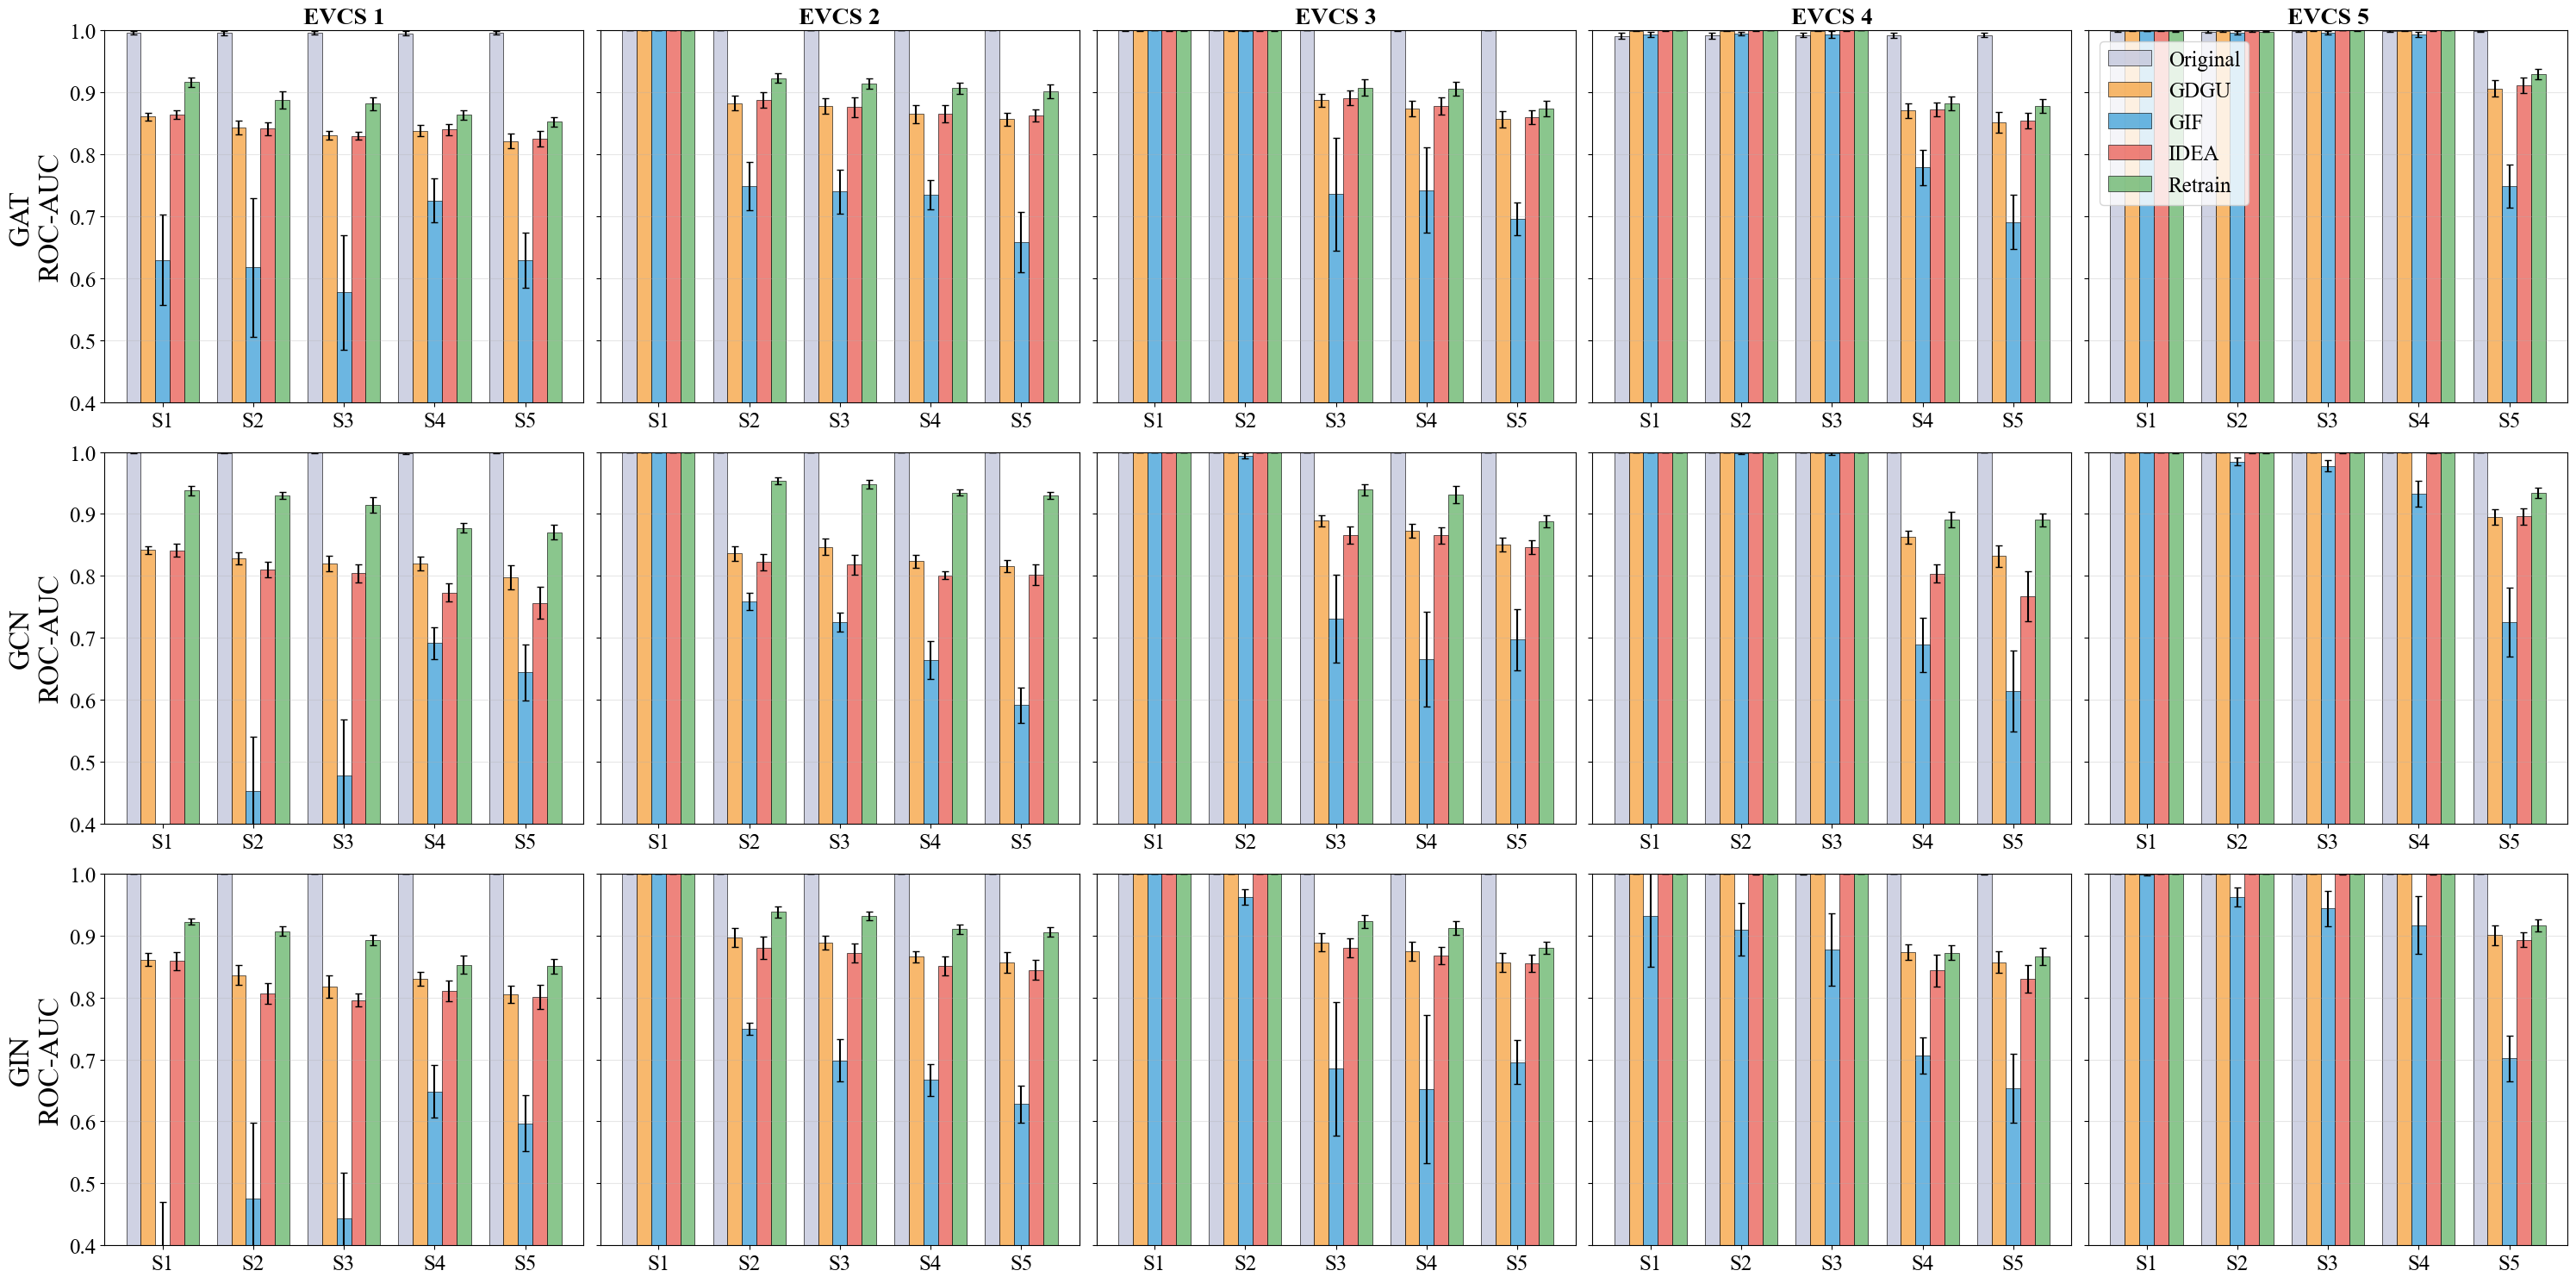

In [9]:
# Cell 9 — Per-EVCS ROC breakdown
plot_per_evcs_roc(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_PerEVCS_ROC.pdf'),
    scenarios, backbones)

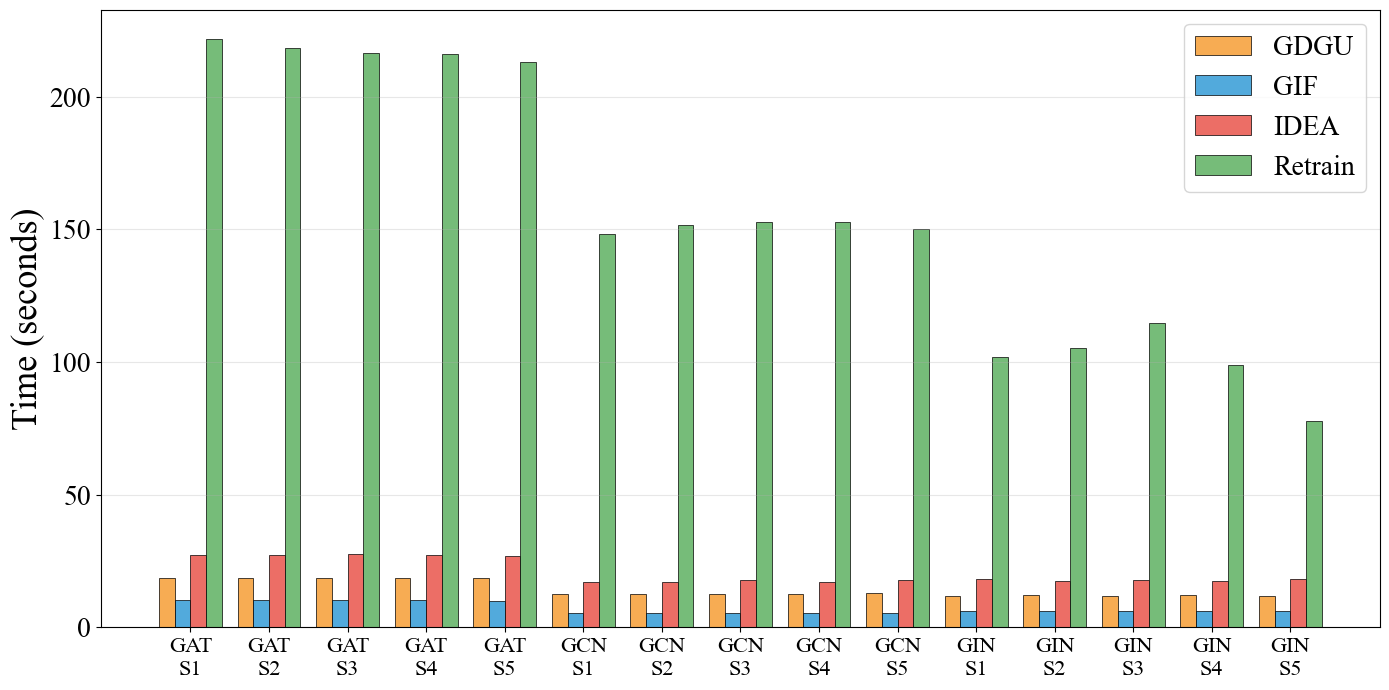

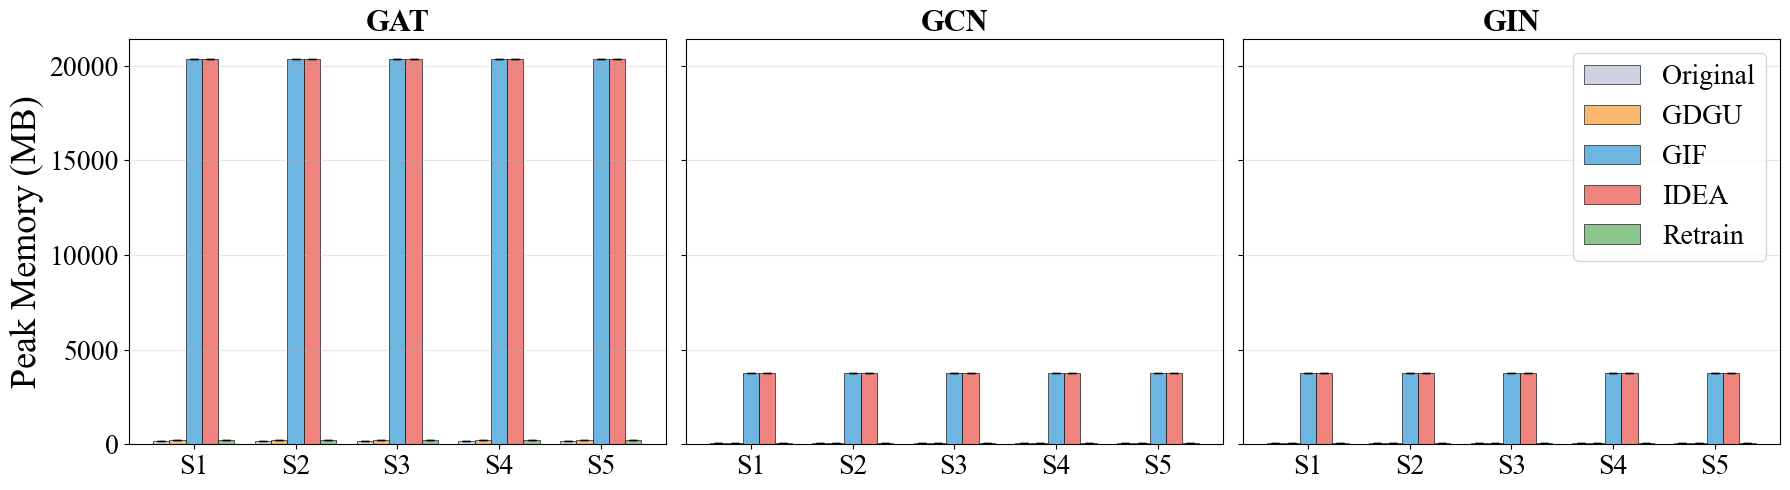

In [10]:
# Cell 10 — Efficiency: time & memory
plot_time_comparison(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Time.pdf'),
    scenarios, backbones)
plot_memory_usage(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_Memory.pdf'),
    scenarios, backbones)

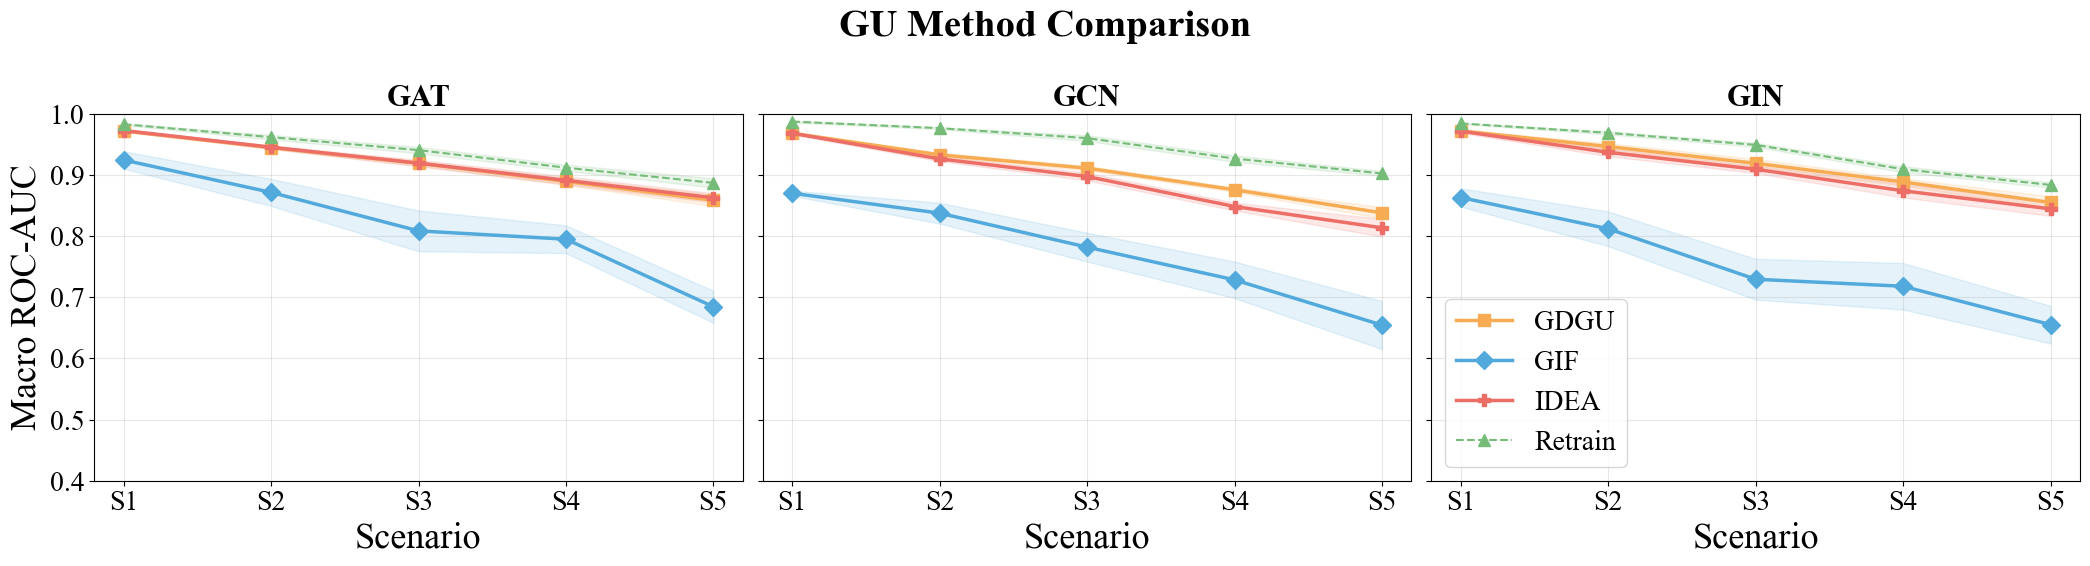

In [11]:
# Cell 11 — GU method comparison (F1 vs Time Pareto)
plot_gu_comparison(df,
    str(RESULTS_DIR / f'{BUS_SYSTEM}_GU_comparison.pdf'),
    scenarios, backbones)

In [12]:
# Cell 12 — Summary tables
import pandas as pd

metrics = ['Macro_ROC', 'Macro_F1', 'ExMatch',
           'L2b_delta_auc', 'L2a_IG_mean', 'Aux_Acc',
           'MIA_forget', 'Time']
metrics = [m for m in metrics if m in df.columns]

summary = (df.groupby(['Backbone', 'Scenario', 'Method'])[metrics]
             .agg(['mean', 'std']).round(4))
display(summary)

# Per-method mean across all backbones and scenarios
overall = df.groupby('Method')[metrics].mean().round(4)
display(overall)

Macro_ROC         Macro_F1         ExMatch          \
                                mean     std     mean     std    mean     std   
Backbone Scenario Method                                                        
GAT      S1       GDGU        0.9719  0.0014   0.9470  0.0035  0.7567  0.0165   
                  GIF         0.9245  0.0143   0.8725  0.0347  0.5510  0.0411   
                  IDEA        0.9727  0.0013   0.9481  0.0039  0.7598  0.0156   
                  Original    0.9972  0.0014   0.9771  0.0072  0.9163  0.0269   
                  Retrain     0.9830  0.0015   0.9560  0.0047  0.8015  0.0210   
...                              ...     ...      ...     ...     ...     ...   
GIN      S5       GDGU        0.8550  0.0099   0.7500  0.0125  0.3813  0.0165   
                  GIF         0.6552  0.0308   0.0815  0.0570  0.1907  0.0135   
                  IDEA        0.8446  0.0113   0.7537  0.0132  0.3543  0.0124   
                  Original    0.9998  0.0002   0.9952  0.0015  0.9823  0.0052   
                  Retrain     0.8837  0.0044   0.7879  0.0088  0.4305  0.0151   

                           L2b_delta_auc         L2a_IG_mean         Aux_Acc  \
                                    mean     std        mean     std    mean   
Backbone Scenario Method                                                       
GAT      S1       GDGU            0.0142  0.0027      1.8811  0.4029  0.6502   
                  GIF             0.0497  0.0104      2.1452  0.4513  0.6918   
                  IDEA            0.0139  0.0027      1.9931  0.3121  0.6562   
                  Original        0.0426  0.0024      6.1418  1.1606  0.7258   
                  Retrain        -0.0217  0.0025      1.3522  0.2739  0.6300   
...                                  ...     ...         ...     ...     ...   
GIN      S5       GDGU            0.0878  0.0080     32.3852  4.5600  0.3285   
                  GIF             0.1430  0.0295     57.8345  9.7123  0.3077   
                  IDEA            0.0220  0.0092      8.3650  2.2072  0.3095   
                  Original        0.3147  0.0257    118.3892  6.7242  0.6128   
                  Retrain         0.0000  0.0000      0.0000  0.0000  0.5238   

                                   MIA_forget              Time           
                               std       mean     std      mean      std  
Backbone Scenario Method                                                  
GAT      S1       GDGU      0.0170     0.5550  0.0117   18.6832   0.2339  
                  GIF       0.0194     0.5441  0.0178   10.2075   0.1991  
                  IDEA      0.0183     0.5531  0.0106   27.3724   0.3645  
                  Original  0.0227        NaN     NaN  220.4586   1.9905  
                  Retrain   0.0259     0.5599  0.0122  221.6169   2.7566  
...                            ...        ...     ...       ...      ...  
GIN      S5       GDGU      0.0225     0.6184  0.0084   11.9394   0.1338  
                  GIF       0.0233     0.5012  0.0031    6.2869   0.0385  
                  IDEA      0.0271     0.5699  0.0124   18.2672   1.6926  
                  Original  0.0106        NaN     NaN  125.6658  21.5898  
                  Retrain   0.0137     0.6768  0.0314   77.7654  13.0164  

[75 rows x 16 columns]

,Macro_ROC,Macro_F1,ExMatch,L2b_delta_auc,L2a_IG_mean,Aux_Acc,MIA_forget,Time
Method,,,,,,,,
GDGU,0.9128,0.8492,0.5404,0.0684,26.9089,0.5124,0.5739,14.3733
GIF,0.7823,0.4955,0.2618,0.1013,31.8415,0.4897,0.5094,7.2999
IDEA,0.9055,0.8445,0.5229,0.0429,11.4209,0.4821,0.5606,20.7964
Original,0.9989,0.9889,0.9600,0.1651,52.6091,0.6685,NaN,163.8451
Retrain,0.9423,0.8850,0.6241,-0.0312,6.5010,0.5592,0.6326,155.9433
